In [1]:
%pip install --upgrade --force-reinstall numpy==2.1.3 scipy==1.14.0 tensorflow==2.19.0 pandas==3.0.3 matplotlib==3.10.9 opencv-python==4.13.0.92 scikit-learn==1.8.0 tqdm==4.67.3

  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.14.0-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB

In [36]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import random
import shutil
from tqdm.auto import tqdm
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import tensorflow as tf

e:\lanenet model major\.venv\Scripts\python.exe


In [37]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
TRAIN_SET_DIR = PROJECT_ROOT / 'train_set'
TEST_SET_DIR = PROJECT_ROOT / 'test_set'
PROCESSED_DIR = PROJECT_ROOT / 'tusimple_processed'
IMAGE_FOLDER = PROCESSED_DIR / 'images'
MASK_FOLDER = PROCESSED_DIR / 'mask'
LABEL_FILES = [
    TRAIN_SET_DIR / 'label_data_0313.json',
    TRAIN_SET_DIR / 'label_data_0531.json',
    TRAIN_SET_DIR / 'label_data_0601.json'
]

In [38]:
def create_directories_if_not_exist(dir_path):
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)
        print('Directory created:', dir_path)
    else:
        print('Directory already exists:', dir_path)

In [39]:
create_directories_if_not_exist(IMAGE_FOLDER)
create_directories_if_not_exist(MASK_FOLDER)

Directory already exists: e:\lanenet model major\tusimple_processed\images
Directory already exists: e:\lanenet model major\tusimple_processed\mask


In [40]:
CLIPS_PATH = TRAIN_SET_DIR / 'clips'

# iterate through each directory
for clip_dir in os.listdir(CLIPS_PATH):
    clip_dir_path = os.path.join(CLIPS_PATH, clip_dir)

    print("Processing Clip:", clip_dir)

    # iterate through each sub directory
    for frame_dir in os.listdir(clip_dir_path):
        frame_path = os.path.join(clip_dir_path, frame_dir, '20.jpg')

        # check if file is present
        if not os.path.isfile(frame_path):
            continue

        # create new filename based on clip directory and frame directory
        temp = Path(frame_path).parts[-3:-1]
        new_filename = f"{temp[0]}_{temp[1]}.jpg"
        new_file_path = os.path.join(IMAGE_FOLDER, new_filename)

        # copy the file
        shutil.copy(frame_path, new_file_path)

Processing Clip: 0313-1
Processing Clip: 0313-2
Processing Clip: 0531
Processing Clip: 0601


In [41]:
print('Total Images in Dataset:', len(os.listdir(IMAGE_FOLDER)))

Total Images in Dataset: 3626


In [42]:
# load the dataset json files
dataframes = [pd.read_json(label_file, lines=True) for label_file in LABEL_FILES]

# combine in single dataframe
df = pd.concat(dataframes, ignore_index=True)

df.head()

,lanes,h_samples,raw_file
0,"[[-2, -2, -2, -2, 632, 625, 617, 609, 601, 594...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/6040/20.jpg
1,"[[-2, -2, -2, 658, 646, 635, 623, 612, 601, 58...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/5320/20.jpg
2,"[[-2, 570, 554, 538, 522, 505, 489, 473, 456, ...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/23700/20.jpg
3,"[[-2, -2, -2, -2, 555, 542, 530, 517, 505, 493...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/51660/20.jpg
4,"[[-2, -2, -2, 522, 525, 528, 531, 534, 537, 53...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/25680/20.jpg


In [43]:
# create function for generating masks
def generate_lane_mask(row):
    # create a mask of all zeros
    mask = np.zeros((720, 1280, 1), dtype=np.uint8)

    # extract data from the row
    h_samples = row.h_samples
    lanes = row.lanes
    raw_file = row.raw_file

    # create mask; lane=1, non-lane=0
    for lane in lanes:
        # exclude -2 datapoints
        h_samples_filtered = [y for x, y in zip(lane, h_samples) if x != -2]
        lane_filtered = [x for x in lane if x != -2]

        # create array of lane points
        lane_points = np.array(list(zip(lane_filtered, h_samples_filtered)))

        # update lane mask
        cv2.polylines(
            mask,
            [lane_points],
            isClosed=False,
            color=(255, 255, 255),
            thickness=15
        )

    # generate mask filename
    temp = Path(raw_file).parts[-3:-1]
    mask_filename = f"{temp[0]}_{temp[1]}.jpg"
    mask_filename_path = os.path.join(MASK_FOLDER, mask_filename)

    # write the mask image
    cv2.imwrite(mask_filename_path, mask)


In [44]:
# generate masks
for index, row in tqdm(df.iterrows(), total=len(df)):
    generate_lane_mask(row)

  0%|          | 0/3626 [00:00<?, ?it/s]

In [45]:
def visualize_image(image_name):
    # get paths
    image_path = os.path.join(IMAGE_FOLDER, image_name)
    mask_path = os.path.join(MASK_FOLDER, image_name)

    # read the image and mask
    image = cv2.imread(str(image_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f'Image not found: {image_path}')
    if mask is None:
        raise FileNotFoundError(f'Mask not found: {mask_path}')

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # plot the image
    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Road Image')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Ground Truth Mask')

    # show the images
    plt.show()


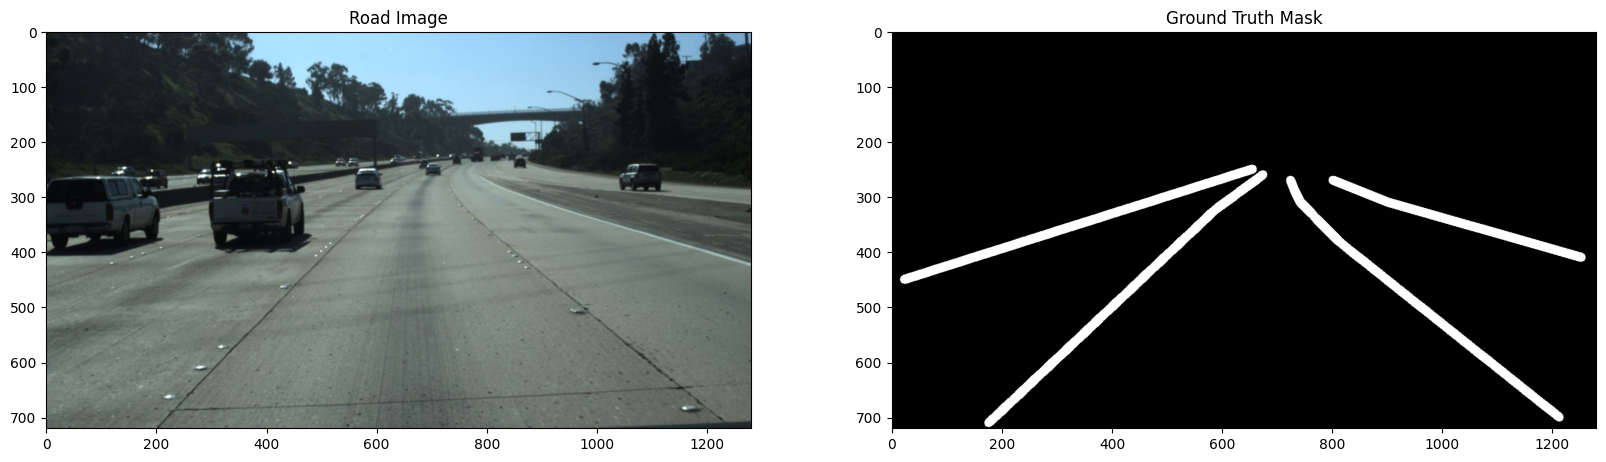

In [46]:
image_name = random.choice(os.listdir(IMAGE_FOLDER))
visualize_image(image_name)


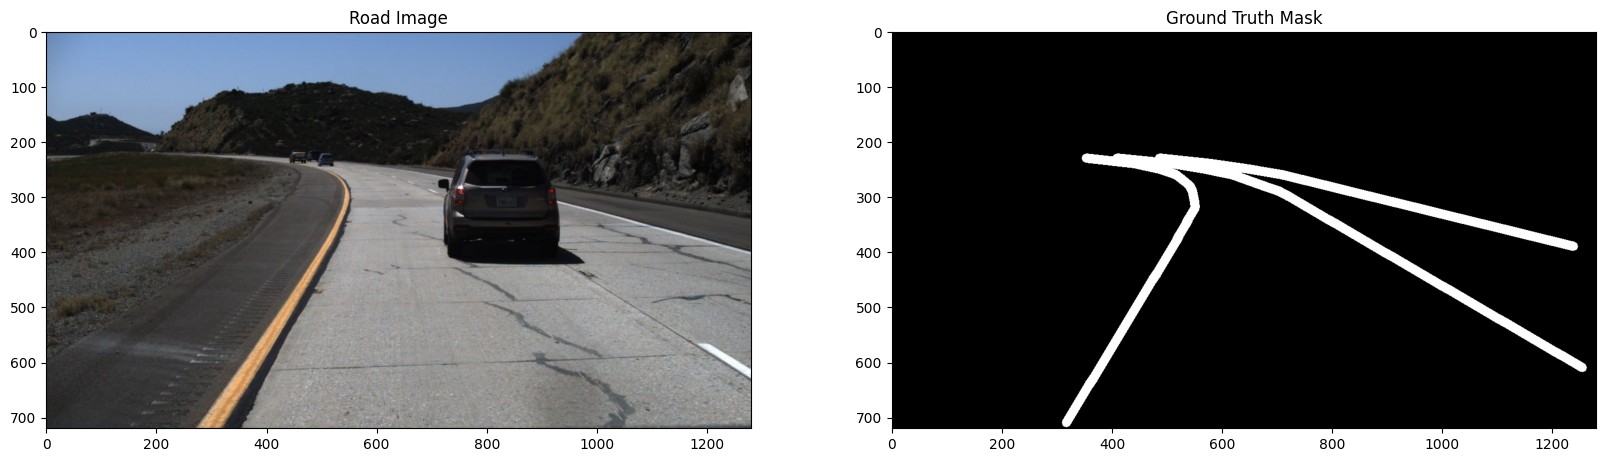

In [48]:
image_name = random.choice(os.listdir(IMAGE_FOLDER))
visualize_image(image_name)


In [49]:
train_image_folder = PROCESSED_DIR / 'train' / 'images'
test_image_folder  = PROCESSED_DIR / 'test' / 'images'

train_mask_folder  = PROCESSED_DIR / 'train' / 'masks'
test_mask_folder   = PROCESSED_DIR / 'test' / 'masks'


In [50]:
for folder_path in (train_image_folder, test_image_folder,
                    train_mask_folder, test_mask_folder):
    create_directories_if_not_exist(folder_path)


Directory already exists: e:\lanenet model major\tusimple_processed\train\images
Directory already exists: e:\lanenet model major\tusimple_processed\test\images
Directory already exists: e:\lanenet model major\tusimple_processed\train\masks
Directory already exists: e:\lanenet model major\tusimple_processed\test\masks


In [51]:
from sklearn.model_selection import train_test_split

images = [file for file in os.listdir(IMAGE_FOLDER) if file.endswith('.jpg')]
masks  = [file for file in os.listdir(MASK_FOLDER) if file.endswith('.jpg')]

# split for train and test
train_images, test_images = train_test_split(
    images,
    test_size=0.1,
    random_state=42
)


In [52]:
len(train_images), len(test_images)

(3263, 363)

In [53]:
# move files to the corresponding folders
for file in train_images:
    # move the image and mask
    source = os.path.join(IMAGE_FOLDER, file)
    destination = os.path.join(train_image_folder, file)
    shutil.move(source, destination)

    source = os.path.join(MASK_FOLDER, file)
    destination = os.path.join(train_mask_folder, file)
    shutil.move(source, destination)

for file in test_images:
    # move the image and mask
    source = os.path.join(IMAGE_FOLDER, file)
    destination = os.path.join(test_image_folder, file)
    shutil.move(source, destination)

    source = os.path.join(MASK_FOLDER, file)
    destination = os.path.join(test_mask_folder, file)
    shutil.move(source, destination)


In [54]:
def load_image(image_path, mask_path):
    size = [224, 224]

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, size)
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, size, method="nearest")  # IMPORTANT
    mask = tf.cast(mask, tf.float32) / 255.0

    return image, mask



def dataset_from_folder(image_folder, mask_folder):
    image_files = sorted(
        [os.path.join(image_folder,file) for file in os.listdir(image_folder) if file.endswith('.jpg')]
    )
    mask_files = sorted(
        [os.path.join(mask_folder,file) for file in os.listdir(mask_folder) if file.endswith('.jpg')]
    )

    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(
        lambda image_path, mask_path: load_image(image_path, mask_path)
    )

    return dataset


In [55]:
# load dataset from folder
train_dataset = dataset_from_folder(train_image_folder, train_mask_folder)
test_dataset  = dataset_from_folder(test_image_folder, test_mask_folder)


In [56]:
# set config
BATCH_SIZE = 32
BUFFER_SIZE = 1000

# optimize for performance improvement
train_dataset = train_dataset.cache().shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)


In [57]:
def display_sample(image_list):
    plt.figure(figsize=(10, 10))

    titles = ['Image', 'True Mask', 'Predicted Mask']

    for i in range(len(image_list)):
        plt.subplot(1, len(image_list), i + 1)
        plt.title(titles[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(image_list[i]))
        plt.axis('off')

    plt.show()


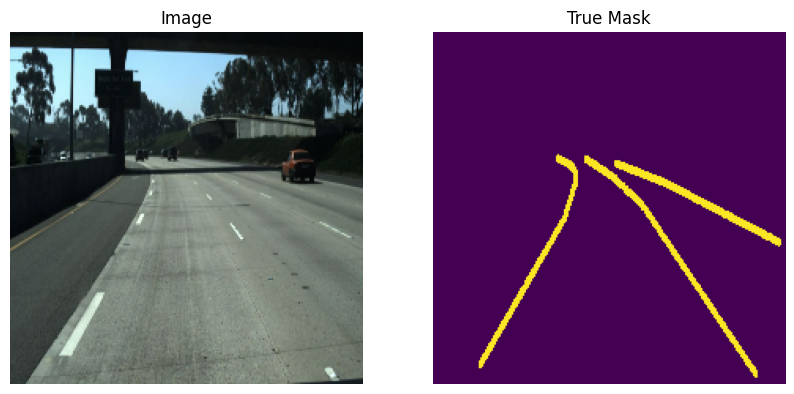

In [58]:
for image, mask in train_dataset.take(1):
    display_sample([image[0], mask[0]])


In [59]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    UpSampling2D,
    Concatenate,
    Dropout,
    BatchNormalization
)

def VGG16_UNet(input_shape=(None, None, 3)):
    '''U net architecture with VGG16 encoder (down/up sampling with skip architecture)'''

    def Conv2DReluBatchNorm(n_filters, kernel_size, strides, inputs):
        x = Conv2D(
            n_filters, (1, 1), strides=1, padding='same',
            kernel_initializer='glorot_normal',
            activation='elu'
        )(inputs)
    
        x = Conv2D(
            n_filters, kernel_size, strides=strides, padding='same',
            kernel_initializer='glorot_normal',
            activation='elu'
        )(x)
    
        x = BatchNormalization()(x)
        x = Dropout(rate=0.25)(x, training=True)  # training + test-time dropout!
        return x
    
    # VGG16 encoder
    vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Unfreeze VGG16 layers
    for layer in vgg16.layers:
        layer.trainable = True

    # Encoder layers
    inputs = vgg16.input
    layer1 = vgg16.get_layer('block1_conv2').output
    layer2 = vgg16.get_layer('block2_conv2').output
    layer3 = vgg16.get_layer('block3_conv3').output
    layer4 = vgg16.get_layer('block4_conv3').output
    layer5 = vgg16.get_layer('block5_conv3').output
    
    # Decoder layers
    merge6 = Concatenate(axis=-1)([UpSampling2D(size=(2, 2))(layer5), layer4])
    layer6 = Conv2DReluBatchNorm(512, (3, 3), (1, 1), merge6)
    
    merge7 = Concatenate(axis=-1)([UpSampling2D(size=(2, 2))(layer6), layer3])
    layer7 = Conv2DReluBatchNorm(256, (3, 3), (1, 1), merge7)
    
    merge8 = Concatenate(axis=-1)([UpSampling2D(size=(2, 2))(layer7), layer2])
    layer8 = Conv2DReluBatchNorm(128, (3, 3), (1, 1), merge8)
    
    merge9 = Concatenate(axis=-1)([UpSampling2D(size=(2, 2))(layer8), layer1])
    layer9 = Conv2DReluBatchNorm(64, (3, 3), (1, 1), merge9)
    
    output = Conv2D(
        1, (1, 1),
        strides=(1, 1),
        activation='sigmoid',
        name='output'
    )(layer9)
    return Model(inputs=inputs, outputs=output)

model = VGG16_UNet(input_shape=(224, 224, 3))  # Adjust input shape as needed


In [60]:
import tensorflow
from tensorflow.keras import backend as K

def dice_coefficient(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    mu = y_pred[:, :, :, 0]
    y_pred_f = K.flatten(mu)
    intersection = K.sum(y_true_f * y_pred_f)
    smooth = 1.0
    return (2 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def recall_smooth(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection / (K.sum(y_true_f) + K.epsilon()))

def precision_smooth(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection / (K.sum(y_pred_f) + K.epsilon()))
def accuracy(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)

    # True positives
    true_positives = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))

    # True negatives
    true_negatives = K.sum(
        K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1))
    )

    # Total pixels
    total_pixels = K.cast(tensorflow.size(y_true_f), K.floatx())

    # Accuracy
    accuracy_value = (true_positives + true_negatives) / total_pixels

    return accuracy_value


In [61]:
# compile the model
model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coefficient, precision_smooth, recall_smooth, accuracy]
)

print('Number of parameters:', model.count_params())


Number of parameters: 18636289


In [62]:
# plot the model
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    expand_nested=False,
    dpi=64
)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [63]:
# create mask from prediction
def create_mask(pred_mask):
    # round to closest
    pred_mask = tf.math.round(pred_mask)
    return pred_mask


def show_predictions(dataset=None, num=1):
    if dataset:
        for images, masks in dataset.take(num):
            pred_mask = model.predict(images)
            pred_mask = create_mask(pred_mask[0])
            display_sample([images[0], masks[0], pred_mask])


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


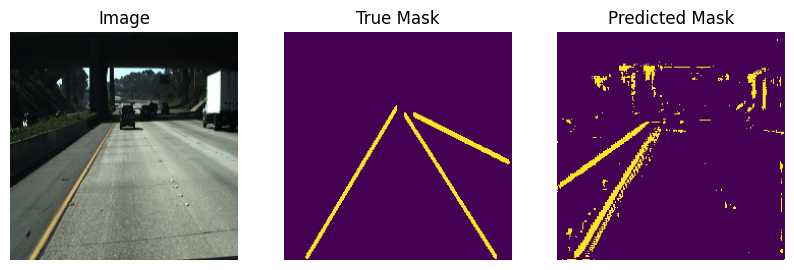

In [66]:
show_predictions(train_dataset, 1)


In [67]:
# callbacks and logs
from tensorflow.keras import callbacks
import datetime

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        show_predictions(test_dataset, 1)
        print(f'Sample Prediction after epoch {epoch}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=-1),
    callbacks.EarlyStopping(patience=5, verbose=1),
    callbacks.ModelCheckpoint('best_model.keras', verbose=1, save_best_only=True)
]


In [68]:
EPOCHS = 10
MAX_STEPS_PER_EPOCH = 10
MAX_VALIDATION_STEPS = 10

full_steps_per_epoch = max(1, len(os.listdir(train_image_folder)) // BATCH_SIZE)
full_validation_steps = max(1, len(os.listdir(test_image_folder)) // BATCH_SIZE)

steps_per_epoch = min(MAX_STEPS_PER_EPOCH, full_steps_per_epoch)
validation_steps = min(MAX_VALIDATION_STEPS, full_validation_steps)

print(f'steps_per_epoch: {steps_per_epoch} / {full_steps_per_epoch}')
print(f'validation_steps: {validation_steps} / {full_validation_steps}')

steps_per_epoch: 10 / 101
validation_steps: 10 / 11


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.6628 - dice_coefficient: 0.1451 - loss: 0.8549 - precision_smooth: 0.0814 - recall_smooth: 0.6897


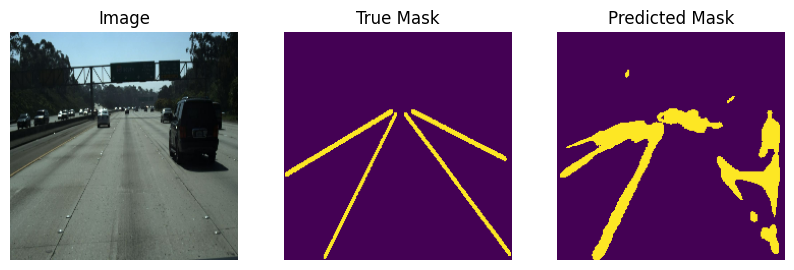

Sample Prediction after epoch 0


Epoch 1: val_loss improved from None to 0.68476, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 438s 41s/step - accuracy: 0.7245 - dice_coefficient: 0.1826 - loss: 0.8174 - precision_smooth: 0.1048 - recall_smooth: 0.7414 - val_accuracy: 0.8974 - val_dice_coefficient: 0.3152 - val_loss: 0.6848 - val_precision_smooth: 0.2201 - val_recall_smooth: 0.5634
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.8587 - dice_coefficient: 0.2861 - loss: 0.7139 - precision_smooth: 0.1759 - recall_smooth: 0.7709


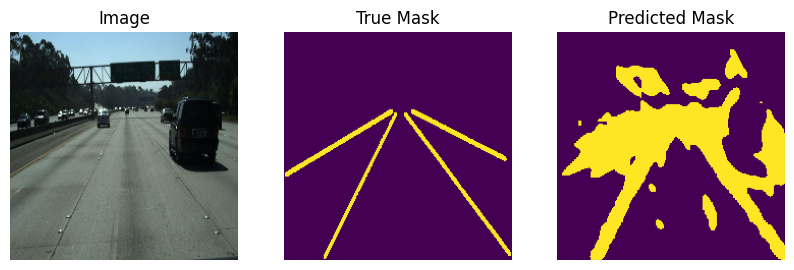

Sample Prediction after epoch 1


Epoch 2: val_loss did not improve from 0.68476
10/10 ━━━━━━━━━━━━━━━━━━━━ 346s 36s/step - accuracy: 0.8724 - dice_coefficient: 0.3045 - loss: 0.6955 - precision_smooth: 0.1898 - recall_smooth: 0.7753 - val_accuracy: 0.7056 - val_dice_coefficient: 0.2086 - val_loss: 0.7914 - val_precision_smooth: 0.1182 - val_recall_smooth: 0.9090
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.9024 - dice_coefficient: 0.3540 - loss: 0.6460 - precision_smooth: 0.2301 - recall_smooth: 0.7680


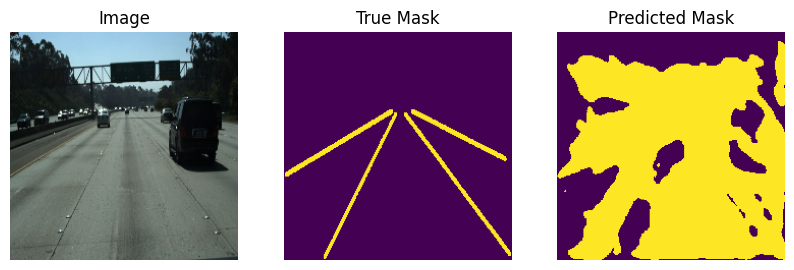

Sample Prediction after epoch 2


Epoch 3: val_loss did not improve from 0.68476
10/10 ━━━━━━━━━━━━━━━━━━━━ 325s 33s/step - accuracy: 0.9087 - dice_coefficient: 0.3651 - loss: 0.6349 - precision_smooth: 0.2400 - recall_smooth: 0.7657 - val_accuracy: 0.3724 - val_dice_coefficient: 0.1166 - val_loss: 0.8834 - val_precision_smooth: 0.0620 - val_recall_smooth: 0.9828
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.9169 - dice_coefficient: 0.3890 - loss: 0.6110 - precision_smooth: 0.2614 - recall_smooth: 0.7617


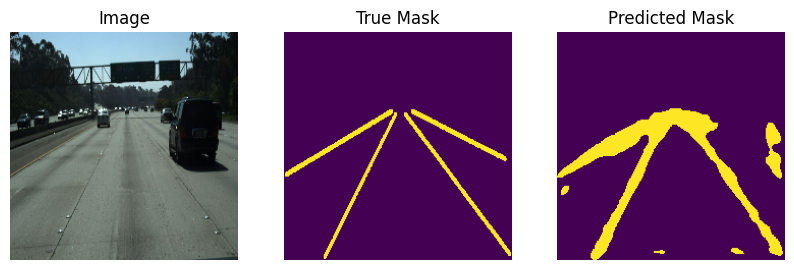

Sample Prediction after epoch 3


Epoch 4: val_loss improved from 0.68476 to 0.55173, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 357s 36s/step - accuracy: 0.9226 - dice_coefficient: 0.4045 - loss: 0.5955 - precision_smooth: 0.2745 - recall_smooth: 0.7704 - val_accuracy: 0.9176 - val_dice_coefficient: 0.4483 - val_loss: 0.5517 - val_precision_smooth: 0.3122 - val_recall_smooth: 0.7957
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.9349 - dice_coefficient: 0.4486 - loss: 0.5514 - precision_smooth: 0.3144 - recall_smooth: 0.7829


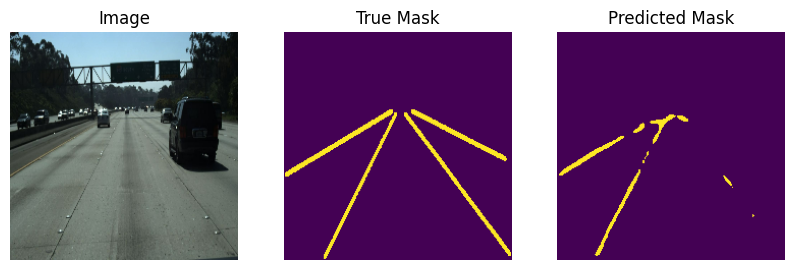

Sample Prediction after epoch 4


Epoch 5: val_loss did not improve from 0.55173
10/10 ━━━━━━━━━━━━━━━━━━━━ 367s 38s/step - accuracy: 0.9378 - dice_coefficient: 0.4608 - loss: 0.5392 - precision_smooth: 0.3252 - recall_smooth: 0.7910 - val_accuracy: 0.9630 - val_dice_coefficient: 0.3054 - val_loss: 0.6946 - val_precision_smooth: 0.7278 - val_recall_smooth: 0.1937
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/stepp - accuracy: 0.9484 - dice_coefficient: 0.4971 - loss: 0.5029 - precision_smooth: 0.3641 - recall_smooth: 0.783


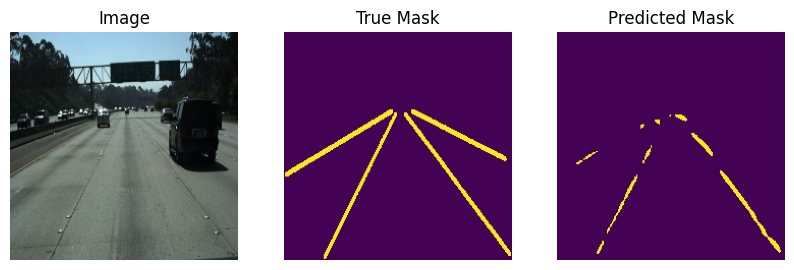

Sample Prediction after epoch 5


Epoch 6: val_loss did not improve from 0.55173
10/10 ━━━━━━━━━━━━━━━━━━━━ 724s 74s/step - accuracy: 0.9492 - dice_coefficient: 0.5035 - loss: 0.4965 - precision_smooth: 0.3701 - recall_smooth: 0.7878 - val_accuracy: 0.9650 - val_dice_coefficient: 0.3706 - val_loss: 0.6294 - val_precision_smooth: 0.7679 - val_recall_smooth: 0.2446
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/stepp - accuracy: 0.9531 - dice_coefficient: 0.5336 - loss: 0.4664 - precision_smooth: 0.4073 - recall_smooth: 0.7753


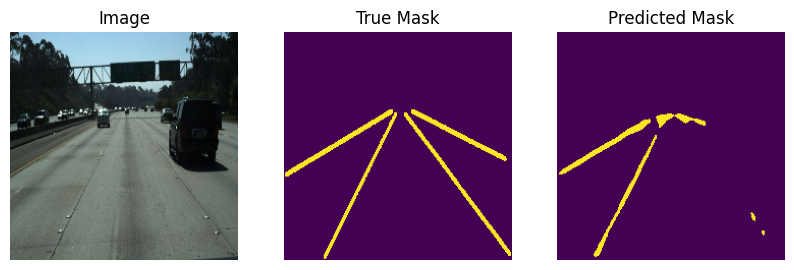

Sample Prediction after epoch 6


Epoch 7: val_loss improved from 0.55173 to 0.48001, saving model to best_model.keras

Epoch 7: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1048s 108s/step - accuracy: 0.9542 - dice_coefficient: 0.5434 - loss: 0.4566 - precision_smooth: 0.4194 - recall_smooth: 0.7724 - val_accuracy: 0.9687 - val_dice_coefficient: 0.5200 - val_loss: 0.4800 - val_precision_smooth: 0.7284 - val_recall_smooth: 0.4077
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/steptep - accuracy: 0.9587 - dice_coefficient: 0.5710 - loss: 0.4290 - precision_smooth: 0.4535 - recall_smooth: 0.7735 


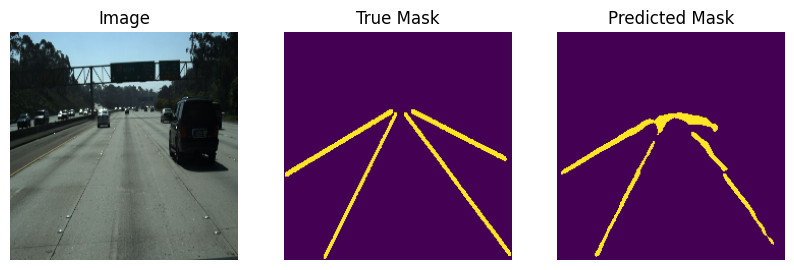

Sample Prediction after epoch 7


Epoch 8: val_loss improved from 0.48001 to 0.40249, saving model to best_model.keras

Epoch 8: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 782s 77s/step - accuracy: 0.9584 - dice_coefficient: 0.5733 - loss: 0.4267 - precision_smooth: 0.4589 - recall_smooth: 0.7657 - val_accuracy: 0.9688 - val_dice_coefficient: 0.5975 - val_loss: 0.4025 - val_precision_smooth: 0.6538 - val_recall_smooth: 0.5507
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.9603 - dice_coefficient: 0.5810 - loss: 0.4190 - precision_smooth: 0.4799 - recall_smooth: 0.7382


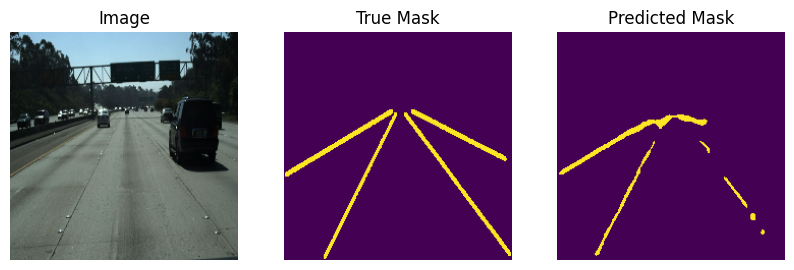

Sample Prediction after epoch 8


Epoch 9: val_loss did not improve from 0.40249
10/10 ━━━━━━━━━━━━━━━━━━━━ 290s 28s/step - accuracy: 0.9604 - dice_coefficient: 0.5879 - loss: 0.4121 - precision_smooth: 0.4852 - recall_smooth: 0.7486 - val_accuracy: 0.9708 - val_dice_coefficient: 0.5598 - val_loss: 0.4402 - val_precision_smooth: 0.7616 - val_recall_smooth: 0.4436
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/steptep - accuracy: 0.9647 - dice_coefficient: 0.6127 - loss: 0.3873 - precision_smooth: 0.5159 - recall_smooth: 0.7547


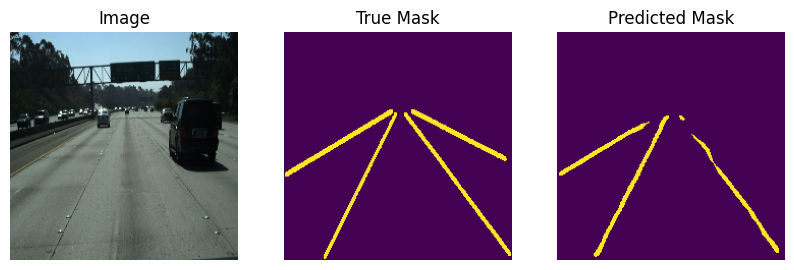

Sample Prediction after epoch 9


Epoch 10: val_loss improved from 0.40249 to 0.37769, saving model to best_model.keras

Epoch 10: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 363s 36s/step - accuracy: 0.9647 - dice_coefficient: 0.6228 - loss: 0.3772 - precision_smooth: 0.5255 - recall_smooth: 0.7649 - val_accuracy: 0.9733 - val_dice_coefficient: 0.6223 - val_loss: 0.3777 - val_precision_smooth: 0.7667 - val_recall_smooth: 0.5247


In [69]:
# train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)

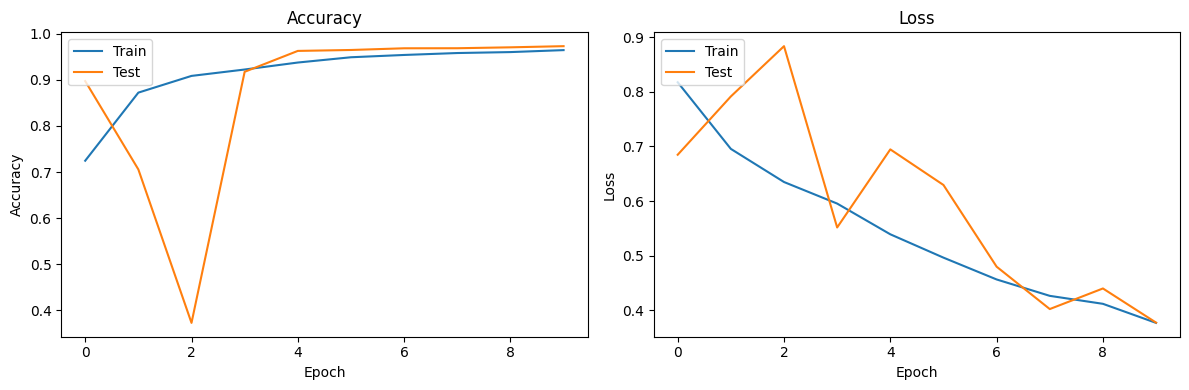

In [70]:
# plot train and val accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# plot train and val loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()


In [71]:
best_model = tf.keras.models.load_model(
    'best_model.keras',
    custom_objects={
        'dice_loss': dice_loss,
        'dice_coefficient': dice_coefficient,
        'precision_smooth': precision_smooth,
        'recall_smooth': recall_smooth,
        'accuracy': accuracy
    }
)

# best_model.compile(optimizer='adam', loss=dice_loss,
#                    metrics=[dice_coefficient, precision_smooth, recall_smooth, accuracy])

best_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 55,905,029 (213.26 MB)

 Trainable params: 18,634,369 (71.08 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 37,268,740 (142.17 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


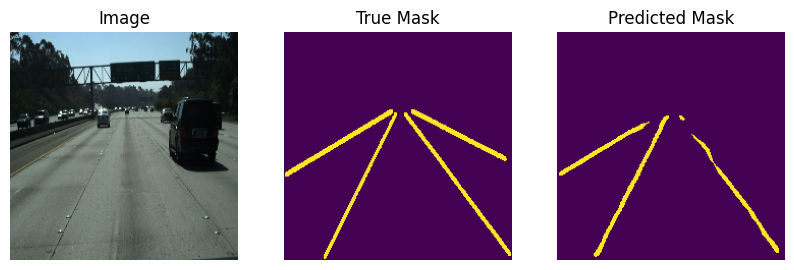

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


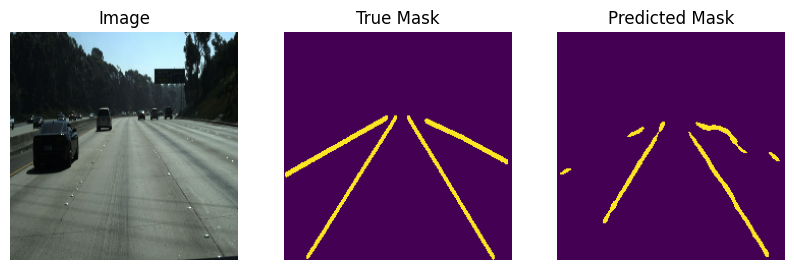

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


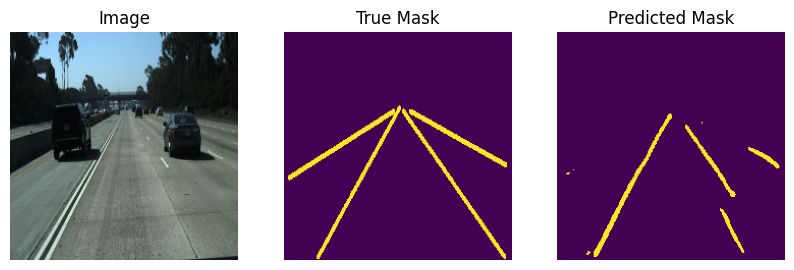

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


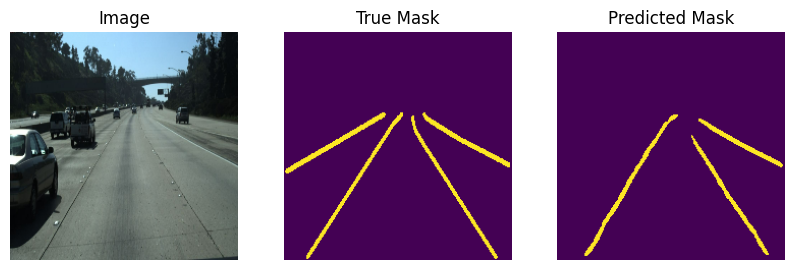

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


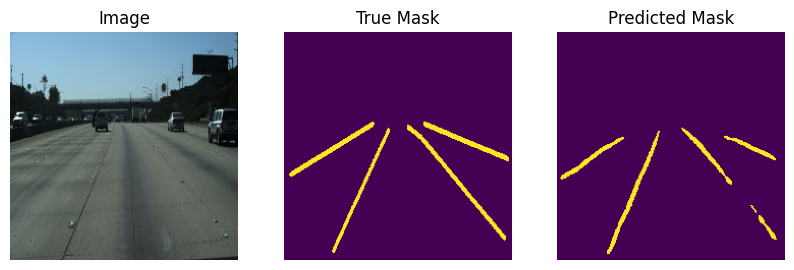

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


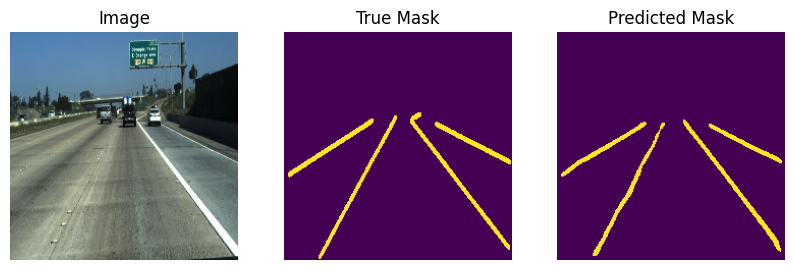

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


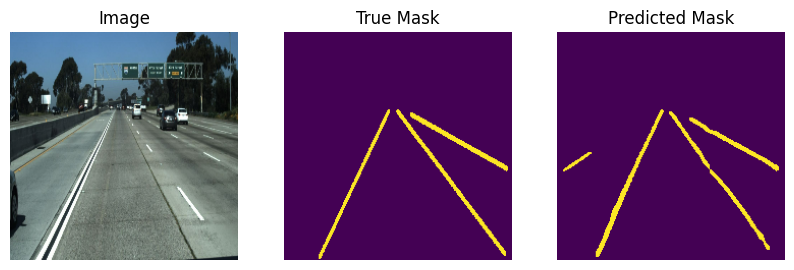

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


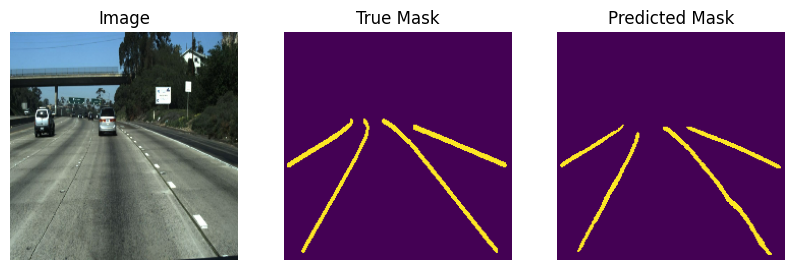

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


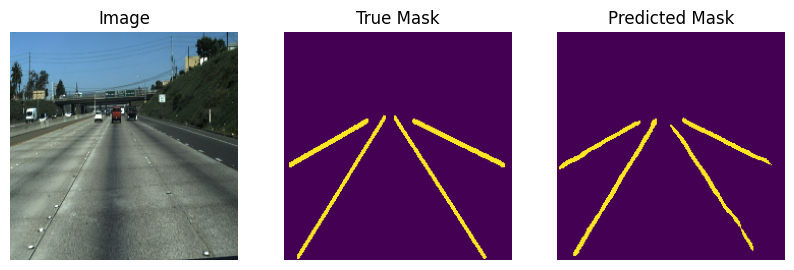

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


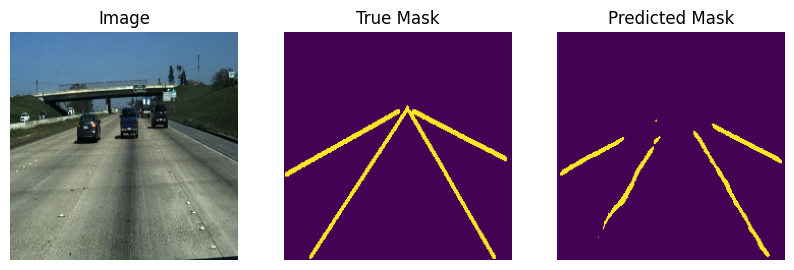

In [72]:
show_predictions(test_dataset, 10)

In [75]:
def load_test_image(image_path):
    size = [224, 224]
    image_path = str(image_path)

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, size)
    image = image / 255.0  # normalize to [0, 1]

    return image


def display_test_sample(image_list):
    plt.figure(figsize=(10, 10))

    titles = ['Image', 'Predicted Mask']

    for i in range(len(image_list)):
        plt.subplot(1, len(image_list), i + 1)
        plt.title(titles[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(image_list[i]))
        plt.axis('off')

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


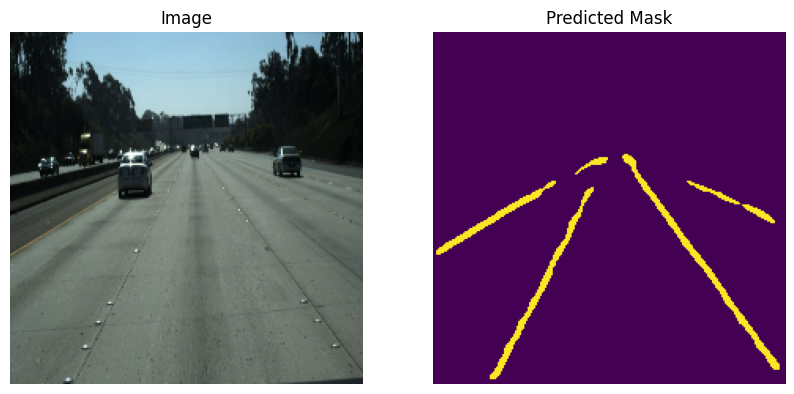

In [78]:
image_path = next(TRAIN_SET_DIR.glob('clips/*/*/20.jpg'))

image = load_test_image(image_path)
test_image = tf.expand_dims(image, axis=0)

pred_mask = best_model.predict(test_image)
pred_mask = create_mask(pred_mask[0])

display_test_sample([image, pred_mask])
